# 🎵 ATLAS — Check the dataset

This notebook:
1. Mounts Google Drive and extracts the GTSinger English subset
2. Explores and validates the directory structure
3. Analyses the dataset (singers, techniques, audio stats, TextGrid annotations)

## 1. Setup & Dependencies

In [1]:
# Install required packages
!pip install -q tgt librosa pandas matplotlib seaborn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.6/41.6 kB 1.0 MB/s eta 0:00:00


In [2]:
import os
import shutil
import zipfile
import json
import random
from pathlib import Path
from collections import defaultdict
from tqdm.notebook import tqdm

import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

try:
    import tgt  # TextGrid tools
except ImportError:
    print("tgt not found — TextGrid parsing will be skipped")
    tgt = None

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── Plot style ─────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

print("Imports OK")

Imports OK


## 2. Mount Google Drive & Define Paths

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
from pathlib import Path

# ── Project paths ──────────────────────────────────────────────────────────────
PROJECT_DIR  = Path("/content/drive/MyDrive/atlas")
ZIP_PATH     = PROJECT_DIR / "English.zip"
META_DIR     = PROJECT_DIR / "metadata2"

# Local (faster I/O than Drive once extracted)
LOCAL_DIR    = Path("/content/atlas")
EXTRACT_DIR  = LOCAL_DIR / "English_raw"
#META_DIR     = LOCAL_DIR / "metadata"

#for d in [LOCAL_DIR, EXTRACT_DIR, META_DIR]:
META_DIR.mkdir(parents=True, exist_ok=True)
print(f"Created: {META_DIR}")

SEED = 42

print(f"Project dir     : {PROJECT_DIR}")
print(f"ZIP source      : {ZIP_PATH}")
print(f"Extract dir     : {EXTRACT_DIR}")
print(f"Metadata        : {META_DIR}")
print(f"ZIP exists      : {ZIP_PATH.exists()}")

Created: /content/drive/MyDrive/atlas/metadata2
Project dir     : /content/drive/MyDrive/atlas
ZIP source      : /content/drive/MyDrive/atlas/English.zip
Extract dir     : /content/atlas/English_raw
Metadata        : /content/drive/MyDrive/atlas/metadata2
ZIP exists      : True


## 3. Unzip English Subset

In [13]:
import zipfile
from tqdm.notebook import tqdm

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

# how many wavs are there
existing_wavs = set(str(p.relative_to(EXTRACT_DIR))
                    for p in EXTRACT_DIR.rglob("*.wav"))
print(f"Already extracted: {len(existing_wavs)} WAVs")

# extract what's missing
with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    all_members = zf.namelist()
    wav_members = [m for m in all_members if m.endswith(".wav")]
    print(f"Total WAVs in ZIP: {len(wav_members)}")

    missing = [m for m in all_members
               if not (EXTRACT_DIR / m).exists()]
    print(f"Missing files: {len(missing)}")

    if missing:
        print("Extracting missing files...")
        for member in tqdm(missing, desc="Extracting"):
            zf.extract(member, EXTRACT_DIR)
        print("Done!")
    else:
        print("Already complete!")

#  verify
wavs = list(EXTRACT_DIR.rglob("*.wav"))
singers = set(p for w in wavs for p in w.parts if "EN-" in p)
print(f"\nFinal WAV count: {len(wavs)}")
print(f"Singers found: {singers}")

already_extracted = EXTRACT_DIR.exists() and any(EXTRACT_DIR.rglob("*.wav"))
if not already_extracted:
    print(f"Unzipping {ZIP_PATH.name} ...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        members = zf.namelist()
        for member in tqdm(members, desc="Extracting"):
            zf.extract(member, EXTRACT_DIR)
    print("Done")
else:
    print("Already extracted — skipping")

Already extracted: 652 WAVs
Total WAVs in ZIP: 6896
Missing files: 22655
Extracting missing files...


Extracting:   0%|          | 0/22655 [00:00<?, ?it/s]

Done!

Final WAV count: 6896
Singers found: {'EN-Alto-1', 'EN-Alto-2', 'EN-Tenor-1'}
Already extracted — skipping


In [16]:
all_files = list(EXTRACT_DIR.rglob("*"))
print(f"Total items (files + dirs) in English_raw: {len(all_files):,}")

wavs = list(EXTRACT_DIR.rglob("*.wav"))
print(f"Total WAV files: {len(wavs)}")

singers = set(p for w in all_files for p in w.parts if "EN-" in p)
print(f"Singers found: {singers}")



Total items (files + dirs) in English_raw: 25,999
Total WAV files: 6896
Singers found: {'EN-Alto-1', 'EN-Alto-2', 'EN-Tenor-1'}


## 4. Explore Directory Structure

In [21]:
#4a. print tree
def print_tree(root: Path, max_depth: int = 4, max_items: int = 6):
    """Print a compact directory tree."""
    def _walk(path: Path, prefix: str, depth: int):
        if depth > max_depth:
            return
        entries = sorted(path.iterdir())
        shown = entries[:max_items]
        hidden = len(entries) - max_items
        for i, entry in enumerate(shown):
            connector = "└── " if i == len(shown) - 1 and hidden <= 0 else "├── "
            print(prefix + connector + entry.name + ("/" if entry.is_dir() else ""))
            if entry.is_dir():
                extension = "    " if connector == "└── " else "│   "
                _walk(entry, prefix + extension, depth + 1)
        if hidden > 0:
            print(prefix + f"└── ... ({hidden} more)")

print(f"{EXTRACT_DIR}/")
_walk = lambda path, prefix, depth: None  # placeholder to avoid NameError below
print_tree(EXTRACT_DIR)

# 4b. detect English root (some zips nest an extra folder)
def find_english_root(base: Path) -> Path:
    """Walk down until we find a directory that looks like the English singer root."""
    for p in base.rglob("*"):
        if p.is_dir() and any(s in p.name for s in ["EN-Tenor", "EN-Alto", "English"]):
            # Return the parent that contains singers
            return p.parent if "EN-" in p.name else p
    return base  # fallback

ENGLISH_ROOT = find_english_root(EXTRACT_DIR)
print(f"English data root: {ENGLISH_ROOT}")

#4c. show actual technique folder names
technique_folders = set()
for p in ENGLISH_ROOT.rglob("*"):
    if p.is_dir() and p.parent.name in ["EN-Alto-1", "EN-Alto-2", "EN-Tenor-1"]:
        technique_folders.add(p.name)

print("Technique folder names found in dataset:")
for f in sorted(technique_folders):
    print(f"  {f}")

/content/atlas/English_raw/
English data root: /content/atlas/English_raw/English
Technique folder names found in dataset:
  Breathy
  Glissando
  Mixed_Voice_and_Falsetto
  Pharyngeal
  Vibrato


In [ ]:
#DELETE
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np

# Hours from GTSinger paper (Table 2) + utterances from your CSV
data = {
    'EN-Tenor-1': {
        'singing_h': 4.76, 'speech_h': 0.87,
        'Mixed V. & Falsetto': 2.06, 'Breathy': 0.69,
        'Pharyngeal': 0.65, 'Vibrato': 0.70, 'Glissando': 0.66,
        'singing_utt': 1845, 'speech_utt': 787,
    },
    'EN-Alto-1': {
        'singing_h': 3.47, 'speech_h': 0.67,
        'Mixed V. & Falsetto': 1.60, 'Breathy': 0.52,
        'Pharyngeal': 0.51, 'Vibrato': 0.28, 'Glissando': 0.56,
        'singing_utt': 1255, 'speech_utt': 537,
    },
    'EN-Alto-2': {
        'singing_h': 4.90, 'speech_h': 1.04,
        'Mixed V. & Falsetto': 2.05, 'Breathy': 0.74,
        'Pharyngeal': 0.67, 'Vibrato': 0.73, 'Glissando': 0.71,
        'singing_utt': 1727, 'speech_utt': 741,
    },
}

techniques  = ['Mixed V. & Falsetto', 'Breathy', 'Pharyngeal', 'Vibrato', 'Glissando']
singers     = list(data.keys())
HEADER_COLOR = '#2c3e50'
ROW_COLORS   = ['#f8f9fa', '#ffffff']
TECH_COLORS  = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']
BORDER_COLOR = '#bdc3c7'

col_x      = [0.15, 1.55, 2.65, 3.65, 4.85, 6.45, 7.85, 9.25, 10.65]
col_w      = [1.30, 1.00, 0.90, 1.10, 1.50, 1.30, 1.30, 1.30, 1.30]
col_labels = ['Singer ID', 'Singing\n(hrs)', 'Speech\n(hrs)', 'Total\nUtterances',
              'Mixed Voice\n& Falsetto', 'Breathy', 'Pharyngeal', 'Vibrato', 'Glissando']
ROW_H    = 0.72
HEADER_Y = 3.30
START_Y  = HEADER_Y - ROW_H

fig = plt.figure(figsize=(13, 4.2))
ax  = fig.add_subplot(111)
ax.set_xlim(0, 13)
ax.set_ylim(0, 4.2)
ax.axis('off')
fig.patch.set_facecolor('white')

# Outer border
ax.add_patch(FancyBboxPatch((0.05, 0.25), 12.85, 3.75,
    boxstyle="round,pad=0.05", linewidth=1.5,
    edgecolor=BORDER_COLOR, facecolor='white', zorder=0))

# Header background
ax.add_patch(FancyBboxPatch((0.05, HEADER_Y - 0.05), 12.85, ROW_H + 0.15,
    boxstyle="square,pad=0", facecolor=HEADER_COLOR, edgecolor='none', zorder=1))

# Sub-headers
ax.text(2.10, HEADER_Y + 0.45, 'Total Hours',
        ha='center', va='center', fontsize=8.5, fontweight='bold', color='white', zorder=2)
ax.text(8.10, HEADER_Y + 0.45, 'Singing Hours per Technique',
        ha='center', va='center', fontsize=8.5, fontweight='bold', color='white', zorder=2)

for x in [1.45, 3.45, 4.55]:
    ax.plot([x, x], [HEADER_Y - 0.05, HEADER_Y + ROW_H + 0.10],
            color='white', linewidth=0.6, alpha=0.4, zorder=3)

for cx, cw, label in zip(col_x, col_w, col_labels):
    ax.text(cx + cw/2, HEADER_Y + 0.20, label,
            ha='center', va='center', fontsize=7.8,
            fontweight='bold', color='white', zorder=2, multialignment='center')

# Data rows
for r, singer in enumerate(singers):
    row_y = START_Y - r * ROW_H
    d = data[singer]
    ax.add_patch(plt.Rectangle((0.05, row_y - 0.05), 12.85, ROW_H,
        facecolor=ROW_COLORS[r % 2], edgecolor='none', zorder=1))
    ax.plot([0.05, 12.90], [row_y - 0.05, row_y - 0.05],
            color=BORDER_COLOR, linewidth=0.5, zorder=2)

    values = [singer, f"{d['singing_h']:.2f}", f"{d['speech_h']:.2f}",
              f"{d['singing_utt'] + d['speech_utt']:,}",
              f"{d['Mixed V. & Falsetto']:.2f}", f"{d['Breathy']:.2f}",
              f"{d['Pharyngeal']:.2f}", f"{d['Vibrato']:.2f}", f"{d['Glissando']:.2f}"]

    for i, (cx, cw, val) in enumerate(zip(col_x, col_w, values)):
        color  = TECH_COLORS[i-4] if i >= 4 else ('#2c3e50' if i == 0 else '#555')
        weight = 'bold' if i == 0 else 'normal'
        ax.text(cx + cw/2, row_y + ROW_H/2 - 0.05, val,
                ha='center', va='center', fontsize=8.2 if i > 0 else 8.5,
                fontweight=weight, color=color, zorder=3)

# Totals row
row_y = START_Y - 3 * ROW_H
ax.add_patch(plt.Rectangle((0.05, row_y - 0.05), 12.85, ROW_H,
    facecolor='#eaf2fb', edgecolor='none', zorder=1))
ax.plot([0.05, 12.90], [row_y - 0.05, row_y - 0.05],
        color=BORDER_COLOR, linewidth=0.8, zorder=2)

totals = ['Total',
          f"{sum(d['singing_h'] for d in data.values()):.2f}",
          f"{sum(d['speech_h']  for d in data.values()):.2f}",
          f"{sum(d['singing_utt']+d['speech_utt'] for d in data.values()):,}"] + \
         [f"{sum(data[s][t] for s in singers):.2f}" for t in techniques]

for i, (cx, cw, val) in enumerate(zip(col_x, col_w, totals)):
    ax.text(cx + cw/2, row_y + ROW_H/2 - 0.05, val,
            ha='center', va='center', fontsize=8.2,
            fontweight='bold', color='#2c3e50', zorder=3)

# Vertical dividers
for x in [1.45, 3.45, 4.55]:
    ax.plot([x, x], [0.20, HEADER_Y + ROW_H + 0.10],
            color=BORDER_COLOR, linewidth=0.7, zorder=2)

# Technique color legend
for i, (tech, color) in enumerate(zip(techniques, TECH_COLORS)):
    lx = 4.60 + i * 1.65
    ax.plot(lx, 0.13, 'o', color=color, markersize=5, zorder=4)
    ax.text(lx + 0.12, 0.13, tech, va='center', fontsize=6.8, color='#555')

# Title
ax.text(6.5, 4.08, 'ATLAS English Subset — GTSinger Statistics',
        ha='center', va='center', fontsize=10, fontweight='bold', color='#2c3e50')

plt.tight_layout(pad=0.3)
plt.savefig(META_DIR / "atlas_dataset_table.png", dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved → atlas_dataset_table.png")

## 5. Inventory: Collect All Files

In [ ]:
# GTSinger folder naming conventions
# Structure: English / <Singer_ID> / <Technique_Folder> / <Group_Folder> / *.wav + *.TextGrid + *.musicxml

TECHNIQUE_KEYWORDS = {
    "Mixed_Voice_and_Falsetto": "mixed_falsetto",
    "Mixed_Voice": "mixed_voice",
    "MixedVoice":  "mixed_voice",
    "Falsetto":    "falsetto",
    "Breathy":     "breathy",
    "Pharyngeal":  "pharyngeal",
    "Vibrato":     "vibrato",
    "Glissando":   "glissando",
}

GROUP_KEYWORDS = {
    "Technique_Group":    "technique",
    "TechniqueGroup":     "technique",
    "Pharyngeal_Group":   "technique",
    "Vibrato_Group":      "technique",
    "Glissando_Group":    "technique",
    "Breathy_Group":      "technique",
    "Mixed_Voice_Group":  "technique",
    "Falsetto_Group":     "technique",
    "Control_Group":      "control",
    "ControlGroup":       "control",
    "Paired_Speech_Group": "speech",
    "PairedSpeech":       "speech",
}


def classify_path(parts, keyword_map):
    for part in parts:
        for kw, label in keyword_map.items():
            if kw.lower() in part.lower():
                return label
    return "unknown"

records = []

for wav in tqdm(list(ENGLISH_ROOT.rglob("*.wav")), desc="Scanning WAV files"):
    if wav.name.startswith("._"):
        continue

    parts = wav.parts
    singer_id = "unknown"
    for part in parts:
        if "EN-" in part:
            singer_id = part
            break

    technique  = classify_path(list(parts), TECHNIQUE_KEYWORDS)
    group      = classify_path(list(parts), GROUP_KEYWORDS)
    song_id    = wav.stem

    # Companion TextGrid
    tg_path = wav.with_suffix(".TextGrid")
    has_textgrid = tg_path.exists()

    # Companion MusicXML
    xml_path = wav.with_suffix(".musicxml")
    has_musicxml = xml_path.exists()

    records.append({
        "singer_id":    singer_id,
        "technique":    technique,
        "group":        group,
        "song_id":      song_id,
        "wav_path":     str(wav),
        "tg_path":      str(tg_path) if has_textgrid else None,
        "xml_path":     str(xml_path) if has_musicxml else None,
        "has_textgrid": has_textgrid,
        "has_musicxml": has_musicxml,
    })

df = pd.DataFrame(records)
print(f"Scanned {len(df):,} utterances")

Scanning WAV files:   0%|          | 0/6892 [00:00<?, ?it/s]

Scanned 6,892 utterances


In [36]:
print("=== ATLAS English Subset Overview ===\n")

for singer in ["EN-Alto-1", "EN-Alto-2", "EN-Tenor-1"]:
    singer_df = df[df["singer_id"] == singer]
    total_utt = len(singer_df)
    total_tg  = singer_df["has_textgrid"].sum()

    print(f"{singer} — {total_utt} utterances, {total_tg} TextGrids:")
    for group in ["technique", "control", "speech"]:
        g_df  = singer_df[singer_df["group"] == group]
        g_utt = len(g_df)
        g_tg  = g_df["has_textgrid"].sum()
        print(f"  ├── {group:10s} : {g_utt} utterances, {g_tg} TextGrids")

    print()

print(f"GRAND TOTAL: {len(df)} utterances, {df['has_textgrid'].sum()} TextGrids")

=== ATLAS English Subset Overview ===

EN-Alto-1 — 1792 utterances, 1251 TextGrids:
  ├── technique  : 718 utterances, 491 TextGrids
  ├── control    : 537 utterances, 380 TextGrids
  ├── speech     : 537 utterances, 380 TextGrids

EN-Alto-2 — 2468 utterances, 1326 TextGrids:
  ├── technique  : 986 utterances, 534 TextGrids
  ├── control    : 741 utterances, 396 TextGrids
  ├── speech     : 741 utterances, 396 TextGrids

EN-Tenor-1 — 2632 utterances, 2632 TextGrids:
  ├── technique  : 1058 utterances, 1058 TextGrids
  ├── control    : 787 utterances, 787 TextGrids
  ├── speech     : 787 utterances, 787 TextGrids

GRAND TOTAL: 6892 utterances, 5209 TextGrids


5b. Extract Ground-Truth Lyrics from Annotations

In [38]:
def extract_lyrics_from_textgrid(tg_path: str) -> str:
    """Extract word-level ground-truth lyrics from a TextGrid file."""
    if not tg_path:
        return ""
    try:
        tg = tgt.io.read_textgrid(tg_path)
        for tier in tg.tiers:
            if "word" in tier.name.lower():
                words = [iv.text.strip() for iv in tier.intervals
                         if iv.text.strip() and iv.text.strip() not in ["", "sil", "sp", "<eps>", "<AP>", "<SP>", "AP", "SP"]]
                return " ".join(words)
    except Exception:
        return ""
    return ""

# Extract lyrics for all utterances with TextGrid
lyrics_list = []
for _, row in tqdm(df.iterrows(), total=len(df), desc="Extracting lyrics"):
    lyrics_list.append(extract_lyrics_from_textgrid(row["tg_path"]))

df["gt_lyrics"] = lyrics_list

# Build clean_name
df["clean_name"] = (df["singer_id"] + "__" + df["technique"] + "__" +
                    df["group"] + "__" + df["song_id"])

print(f"Utterances with lyrics: {(df['gt_lyrics'].str.len() > 0).sum():,}")
print()
print(df[["singer_id", "technique", "group", "gt_lyrics"]].head(5).to_string())

Extracting lyrics:   0%|          | 0/6892 [00:00<?, ?it/s]

Utterances with lyrics: 5,209

    singer_id       technique      group                                                                    gt_lyrics
0  EN-Tenor-1  mixed_falsetto  technique  i know you will i know you will i know that you will will you still love me
1  EN-Tenor-1  mixed_falsetto  technique                 will you still love me when i got nothing but my aching soul
2  EN-Tenor-1  mixed_falsetto  technique                                                 when i'm no longer beautiful
3  EN-Tenor-1  mixed_falsetto  technique                will you still love me when i'm no longer young and beautiful
4  EN-Tenor-1  mixed_falsetto  technique           the crazy days city lights the way you'd play with me like a child


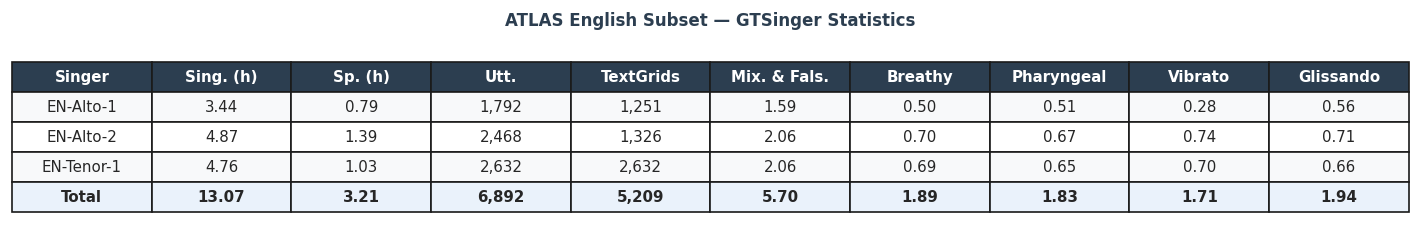

Saved as atlas_dataset_table.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Data df ────────────────────────────────────────────────────────────────
SINGERS    = ["EN-Alto-1", "EN-Alto-2", "EN-Tenor-1"]
TECHNIQUES = ['mixed_falsetto','breathy','pharyngeal','vibrato','glissando']
TECH_DISPLAY = {
    'mixed_falsetto': 'Mix. & Fals.',
    'breathy':        'Breathy',
    'pharyngeal':     'Pharyngeal',
    'vibrato':        'Vibrato',
    'glissando':      'Glissando',
}

singing_df    = df[df["group"].isin(["technique","control"])]
speech_df     = df[df["group"] == "speech"]
singing_hours = singing_df.groupby("singer_id")["duration_h"].sum()
speech_hours  = speech_df.groupby("singer_id")["duration_h"].sum()
tech_hours    = singing_df.groupby(["singer_id","technique"])["duration_h"].sum().unstack()
singing_utt   = singing_df.groupby("singer_id").size()
speech_utt    = speech_df.groupby("singer_id").size()
has_tg        = df.groupby("singer_id")["has_textgrid"].sum()

# ── Table data ─────────────────────────────────────────────────────────────────
col_labels = ['Singer', 'Sing. (h)', 'Sp. (h)', 'Utt.', 'TextGrids'] + \
             [TECH_DISPLAY[t] for t in TECHNIQUES]

rows = []
for singer in SINGERS:
    row = [
        singer,
        f"{singing_hours[singer]:.2f}",
        f"{speech_hours[singer]:.2f}",
        f"{singing_utt[singer]+speech_utt[singer]:,}",
        f"{int(has_tg[singer]):,}",
    ] + [f"{tech_hours.loc[singer,t]:.2f}" for t in TECHNIQUES]
    rows.append(row)

# Totals
rows.append([
    'Total',
    f"{singing_hours.sum():.2f}",
    f"{speech_hours.sum():.2f}",
    f"{(singing_utt+speech_utt).sum():,}",
    f"{int(has_tg.sum()):,}",
] + [f"{tech_hours[t].sum():.2f}" for t in TECHNIQUES])

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 2.2))
ax.axis('off')

table = ax.table(
    cellText=rows,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.6)

# Header style
for j in range(len(col_labels)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Alternating row colors
for i in range(1, len(rows)):
    for j in range(len(col_labels)):
        if i == len(rows):  # totals row
            table[i, j].set_facecolor('#eaf2fb')
            table[i, j].set_text_props(fontweight='bold')
        else:
            table[i, j].set_facecolor('#f8f9fa' if i % 2 == 1 else 'white')

# Totals row bold
for j in range(len(col_labels)):
    table[len(rows), j].set_facecolor('#eaf2fb')
    table[len(rows), j].set_text_props(fontweight='bold')

plt.title('ATLAS English Subset — GTSinger Statistics',
          fontsize=10, fontweight='bold', pad=10, color='#2c3e50')

plt.tight_layout()
plt.savefig(META_DIR / "atlas_dataset_table.png", dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved as atlas_dataset_table.png")

5c. Save Full Metadata

In [48]:
# Save full metadata
meta_path = META_DIR / "atlas_english_metadata.csv"
df.to_csv(meta_path, index=False)
print(f" Metadata saved in {meta_path}")
print(f"Shape: {df.shape}")

# Save WAV manifests
singing_df = df[df["group"].isin(["control", "technique"])]
speech_df  = df[df["group"] == "speech"]

(META_DIR / "singing_wav_list.txt").write_text("\n".join(singing_df["wav_path"].tolist()))
(META_DIR / "speech_wav_list.txt").write_text("\n".join(speech_df["wav_path"].tolist()))
(META_DIR / "all_wav_list.txt").write_text("\n".join(df["wav_path"].tolist()))

print(f"WAV manifests saved")
print(f"   Singing: {len(singing_df):,} utterances")
print(f"   Speech : {len(speech_df):,} utterances")
print(f"   Total  : {len(df):,} utterances")

 Metadata saved in /content/drive/MyDrive/atlas/metadata2/atlas_english_metadata.csv
Shape: (6892, 13)
WAV manifests saved
   Singing: 4,827 utterances
   Speech : 2,065 utterances
   Total  : 6,892 utterances


## 6. Audio Analysis

In [ ]:
# Sample a subset for quick duration analysis
SAMPLE_N = min(200, len(df))
sample_df = df.sample(SAMPLE_N, random_state=SEED).copy()

durations = []
sample_rates = []

for _, row in tqdm(sample_df.iterrows(), total=SAMPLE_N, desc="Reading audio metadata"):
    try:
        info = librosa.get_samplerate(row["wav_path"])
        y, sr = librosa.load(row["wav_path"], sr=None, mono=True)
        durations.append(len(y) / sr)
        sample_rates.append(sr)
    except Exception as e:
        durations.append(np.nan)
        sample_rates.append(np.nan)

sample_df["duration_s"] = durations
sample_df["sample_rate"] = sample_rates

print("=== Audio Stats (sampled) ===")
print(sample_df["duration_s"].describe().round(3))
print(f"\nSample rates observed: {set(sample_rates) - {np.nan}}")

Reading audio metadata:   0%|          | 0/200 [00:00<?, ?it/s]

=== Audio Stats (sampled) ===
count    200.000
mean       8.197
std        3.424
min        1.187
25%        6.127
50%        8.034
75%        9.758
max       19.864
Name: duration_s, dtype: float64

Sample rates observed: {48000}


/tmp/ipython-input-210/749155414.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sample_df, x="technique", y="duration_s", order=order, ax=ax, palette="muted")
/tmp/ipython-input-210/749155414.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8)
/tmp/ipython-input-210/749155414.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sample_df, x="singer_id", y="duration_s", ax=ax, palette="pastel")
/tmp/ipython-input-210/749155414.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.

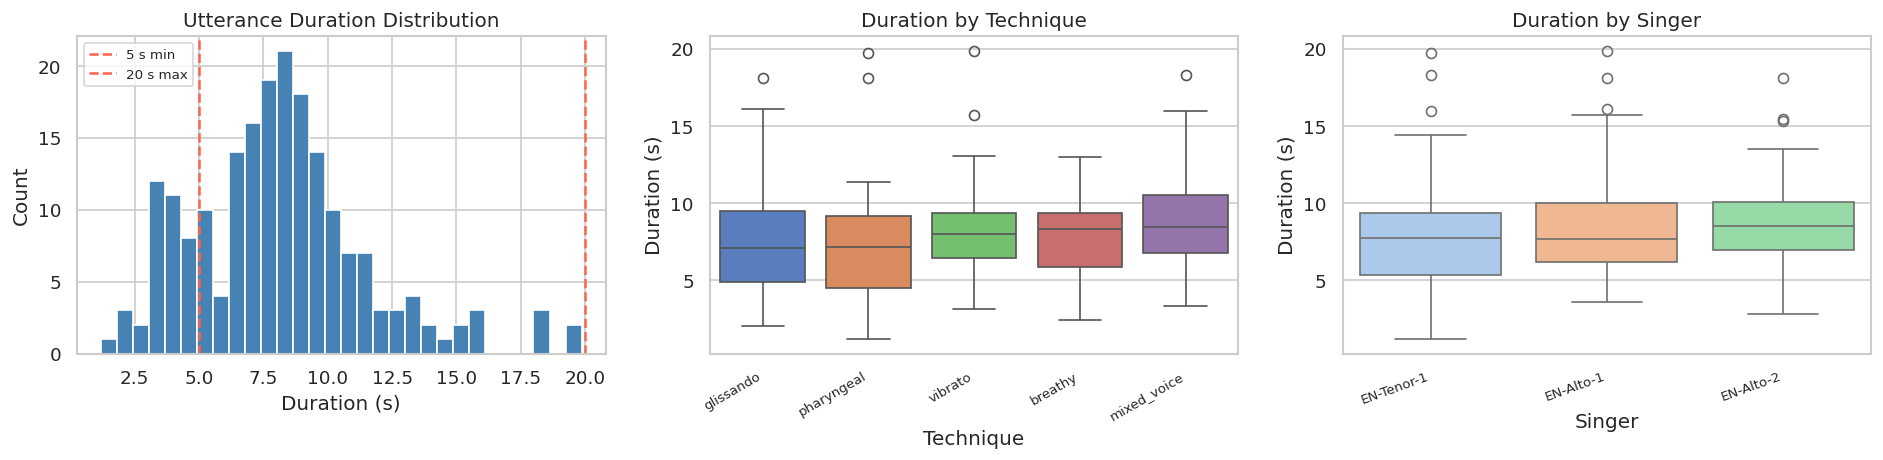

Saved → duration_analysis.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Duration histogram
ax = axes[0]
ax.hist(sample_df["duration_s"].dropna(), bins=30, color="steelblue", edgecolor="white")
ax.axvline(5,  color="tomato", linestyle="--", label="5 s min")
ax.axvline(20, color="tomato", linestyle="--", label="20 s max")
ax.set_xlabel("Duration (s)")
ax.set_ylabel("Count")
ax.set_title("Utterance Duration Distribution")
ax.legend(fontsize=8)

# Duration by technique
ax = axes[1]
order = sample_df.groupby("technique")["duration_s"].median().sort_values().index
sns.boxplot(data=sample_df, x="technique", y="duration_s", order=order, ax=ax, palette="muted")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8)
ax.set_xlabel("Technique")
ax.set_ylabel("Duration (s)")
ax.set_title("Duration by Technique")

# Duration by singer
ax = axes[2]
sns.boxplot(data=sample_df, x="singer_id", y="duration_s", ax=ax, palette="pastel")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right", fontsize=8)
ax.set_xlabel("Singer")
ax.set_ylabel("Duration (s)")
ax.set_title("Duration by Singer")

plt.tight_layout()
plt.savefig(META_DIR / "duration_analysis.png", bbox_inches="tight")
plt.show()
print("Saved → duration_analysis.png")

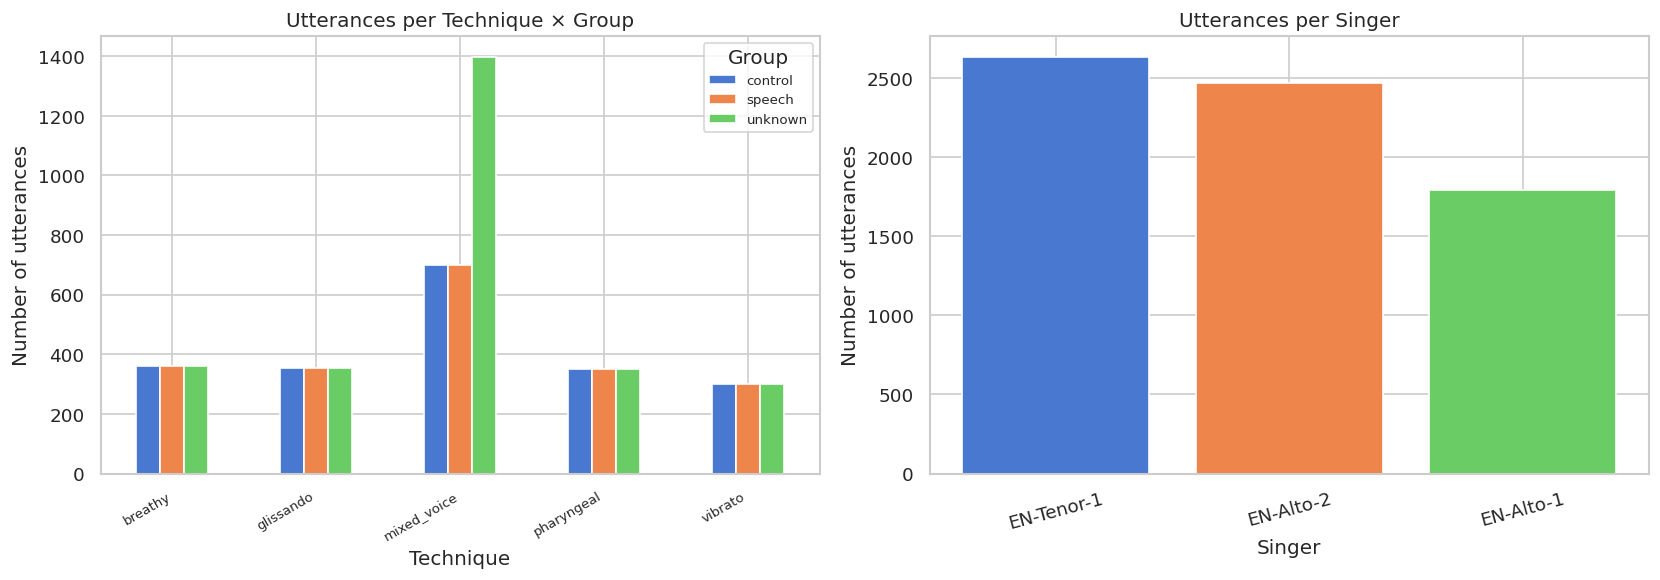

Saved → utterance_counts.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Utterances per technique × group
ax = axes[0]
pivot = df.groupby(["technique", "group"]).size().unstack(fill_value=0)
pivot.plot(kind="bar", ax=ax, edgecolor="white")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8)
ax.set_xlabel("Technique")
ax.set_ylabel("Number of utterances")
ax.set_title("Utterances per Technique × Group")
ax.legend(title="Group", fontsize=8)

# Utterances per singer
ax = axes[1]
singer_counts = df["singer_id"].value_counts().reset_index()
singer_counts.columns = ["singer_id", "count"]
ax.bar(singer_counts["singer_id"], singer_counts["count"], color=sns.color_palette("muted")[:len(singer_counts)])
ax.set_xlabel("Singer")
ax.set_ylabel("Number of utterances")
ax.set_title("Utterances per Singer")
ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig(META_DIR / "utterance_counts.png", bbox_inches="tight")
plt.show()
print("Saved → utterance_counts.png")